In [ ]:
# SPDX-License-Identifier: CC-BY-4.0
# Code for "Active Continual Learning with Metaplastic Binary Bayesian Neural Networks"
# Kellian Cottart, Théo Ballet, Djohan Bonnet, Damien Querlioz
# Portions of the code are adapted from the Pytorch project (BSD-3-Clause)
# Author: Kellian Cottart <kellian.cottart@gmail.com>
# Date: 2025-30-01

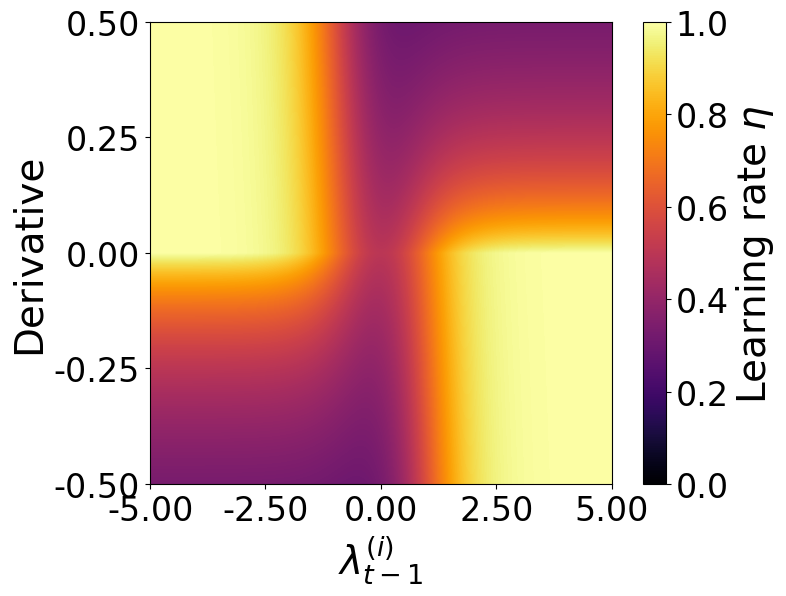

In [1]:

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import os
import seaborn as sns
AXESSIZE = 28
FONTSIZE = 26
TICKSIZE = 24   
LEGENDSIZE = 26
plt.rcParams['svg.fonttype'] = 'none'

FOLDER = "figures-misc"
os.makedirs(FOLDER, exist_ok=True)
def learning_rate(lbda, grad, alpha_max):
    f = 2*jnp.abs(grad) + 1/alpha_max
    g = 1-jnp.tanh(lbda)**2
    h = 2*jnp.tanh(lbda)*grad 
    return 1.0 / (f+g+h)
# we want a colormap that indicates which learning rate depending on lbda and gradient
nb_points = 500
bound_lbd = 5
lbda = jnp.linspace(-bound_lbd, bound_lbd, nb_points)
bound_grad = 0.5
grad = jnp.linspace(-bound_grad, bound_grad, nb_points)

lbda, grad = jnp.meshgrid(lbda, grad)
alpha_max = 1
lr = learning_rate(lbda, grad, alpha_max)
plt.figure(figsize=(8, 6))
plt.imshow(lr, cmap="inferno", vmin=0, vmax=alpha_max, origin='lower')
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=TICKSIZE)
cbar.ax.set_ylabel('Learning rate $\eta$', fontsize=AXESSIZE)

plt.xlabel(r"$\lambda_{t-1}^{(i)}$", fontsize=AXESSIZE)
plt.ylabel(r"Derivative", fontsize=AXESSIZE)
n_pt = 5
xticks = jnp.linspace(0, nb_points, n_pt)
yticks = jnp.linspace(0, nb_points, n_pt)
xlabels = jnp.linspace(-bound_lbd, bound_lbd, n_pt)
ylabels = jnp.linspace(-bound_grad, bound_grad, n_pt)
# allow only 2 digits after the comma
xlabels = [f"{x:.2f}" for x in xlabels]
ylabels = [f"{y:.2f}" for y in ylabels]

plt.xticks(ticks=xticks, labels=xlabels, fontsize=TICKSIZE, rotation=0)
plt.yticks(ticks=yticks, labels=ylabels, fontsize=TICKSIZE, rotation=0)
plt.savefig(f"{FOLDER}/learning_rate_color_map.pdf", bbox_inches='tight')
plt.savefig(f"{FOLDER}/learning_rate_color_map.svg", bbox_inches='tight')

plt.show()

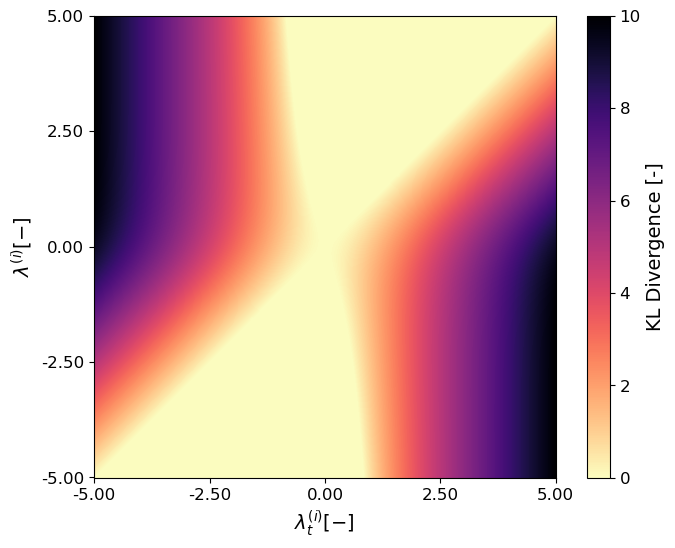

In [2]:

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import os
import seaborn as sns
FONTSIZE = 14
TICKSIZE = 12   
FOLDER = "figures-misc"
os.makedirs(FOLDER, exist_ok=True)
def kldiv(lbda, ldba_t):
    return jnp.tanh(lbda) *(lbda - ldba_t) - jnp.log(jnp.cosh(lbda_t)/jnp.cosh(lbda))
# we want a colormap that indicates which learning rate depending on lbda and gradient
nb_points = 500
bound_lbd = 5
lbda = jnp.linspace(-bound_lbd, bound_lbd, nb_points)
lbda, lbda_t = jnp.meshgrid(lbda, lbda)
kl_score = kldiv(lbda, lbda_t)
plt.figure(figsize=(8, 6))
plt.imshow(kl_score, cmap="magma_r", vmin=0, vmax=10, origin='lower')
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=TICKSIZE)
cbar.ax.set_ylabel('KL Divergence [-]', fontsize=FONTSIZE)

plt.xlabel(r"$\lambda_t^{(i)} [-]$", fontsize=FONTSIZE)
plt.ylabel(r"$\lambda^{(i)} [-]$", fontsize=FONTSIZE)
n_pt = 5
xticks = jnp.linspace(0, nb_points, n_pt)
yticks = jnp.linspace(0, nb_points, n_pt)
xlabels = jnp.linspace(-bound_lbd, bound_lbd, n_pt)
ylabels = jnp.linspace(-bound_lbd, bound_lbd, n_pt)
# allow only 2 digits after the comma
xlabels = [f"{x:.2f}" for x in xlabels]
ylabels = [f"{y:.2f}" for y in ylabels]

plt.xticks(ticks=xticks, labels=xlabels, fontsize=TICKSIZE, rotation=0)
plt.yticks(ticks=yticks, labels=ylabels, fontsize=TICKSIZE, rotation=0)
plt.savefig(f"{FOLDER}/learning_rate_kl_div.pdf", bbox_inches='tight')
plt.savefig(f"{FOLDER}/learning_rate_kl_div.svg", bbox_inches='tight')

plt.show()

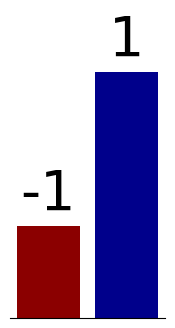

In [3]:
# barplot with darkred and darkblue given two probability
p1 = 0.3
p2 = 0.8
p = jnp.array([p1, p2])
plt.figure(figsize=(2, 4))
plt.bar(["$p_1$", "$p_2$"], p, color=["darkred", "darkblue"])
# put -1 in the middle of the bar of p1
plt.text(0, p1+0.1, "-1", ha='center', va='center', fontsize=40, color="black")
# put 1 in the middle of the bar of p2
plt.text(1, p2+0.1, "1", ha='center', va='center', fontsize=40, color="black")

plt.ylim(0, 1)
# remove labels
plt.xticks([])
plt.yticks([])
# remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)


plt.savefig(f"{FOLDER}/barplot_probabilities.pdf", bbox_inches='tight')
plt.savefig(f"{FOLDER}/barplot_probabilities_{p1}_{p2}.svg", bbox_inches='tight')
plt.show()